# **Fine tune with ResNet152V2**

In [5]:
from src.spectograms import SpectogramConfig
from src.image_preprocessor import ImagePreprocessorConfig, ImagePreprocessor
from src.model_trainer import ModelTrainer
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

In [ ]:
config = SpectogramConfig(
    audio_dir="/content/drive/My Drive/data_passerifromes/paths_cantos_passeriformes.csv",
    out_dir="/content/drive/My Drive/images_spectograms/"
)

In [ ]:
spectograms_path = config.spectograms_paths()
spectograms_path.head(3)

In [6]:
imag_prep_conif = ImagePreprocessorConfig(
    img_size=(128, 256),
    channels=1,
    batch_size=64,
    aug_proba=0.7
)

preprocessor = ImagePreprocessor(config.out_dir)
data = preprocessor.load_data_from_directory("/content/images_spectograms")

(269548, 2)


,label,image_path
0,Acropternis orthonyx,/content/images_spectograms/Acropternis orthon...
1,Acropternis orthonyx,/content/images_spectograms/Acropternis orthon...
2,Acropternis orthonyx,/content/images_spectograms/Acropternis orthon...
3,Acropternis orthonyx,/content/images_spectograms/Acropternis orthon...
4,Acropternis orthonyx,/content/images_spectograms/Acropternis orthon...


#### Check augmentation

In [122]:
rec = data.sample(1).iloc[0]
rec

,4167
label,Anisognathus igniventris
image_path,/content/images_spectograms/Anisognathus igniv...
path_img,/content/images_spectograms/Anisognathus igniv...


(TensorShape([128, 256, 1]), tf.float32, 1.875, 249.82812)
(TensorShape([128, 256, 1]), tf.float32, 0.0, 223.25)
(TensorShape([128, 256, 1]), tf.float32, 0.0, 255.0)
(TensorShape([128, 256, 1]), tf.float32, 0.0, 255.0)
(TensorShape([128, 256, 1]), tf.float32, 0.0, 226.25)
(TensorShape([128, 256, 1]), tf.float32, 0.0, 255.0)
(TensorShape([128, 256, 1]), tf.float32, 0.0, 255.0)
(TensorShape([128, 256, 1]), tf.float32, 0.0, 255.0)
(TensorShape([128, 256, 1]), tf.float32, 0.0, 255.0)
(TensorShape([128, 256, 1]), tf.float32, 0.0, 255.0)
(TensorShape([128, 256, 1]), tf.float32, 0.0, 223.25)
(TensorShape([128, 256, 1]), tf.float32, 0.0, 228.875)


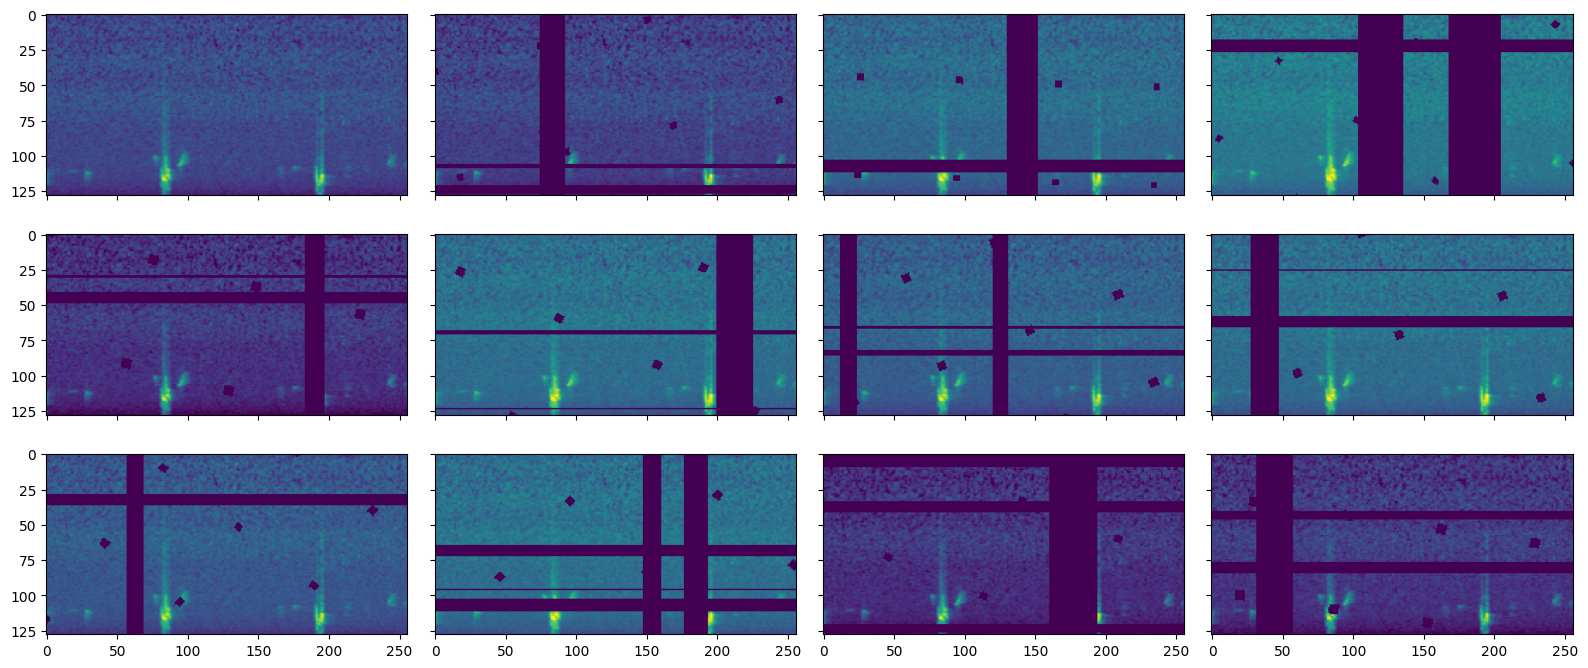

In [123]:
def show_img_stats(img):
    if isinstance(img, tf.Tensor):
        print((img.shape, img.dtype, img.numpy().min(), img.numpy().max()))
    elif isinstance(img, np.array):
        print((img.shape, img.dtype, img.min(), img.max()))
    else:
        print(f"unexpected type: {type(img)}")

img = preprocessor.read_image(rec.image_path)
fig, axs = plt.subplots(3, 4, sharex='all', sharey='all', figsize=(16, 7))
for i, ax in enumerate(axs.flat):
    if i == 0:
        ax.imshow(img, cmap='viridis')
        show_img_stats(img)
    else:
        img1 = preprocessor.augment_image(img)
        ax.imshow(img1, cmap='viridis')
        show_img_stats(img1)
plt.tight_layout()
plt.show()

#### Check dataset

In [124]:
dev_data = data.sample(500)
dev_ds = preprocessor.create_training_dataset(dev_data)
dev_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 256, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 667), dtype=tf.float32, name=None))>

In [125]:
elem = next(iter(dev_ds.take(1)))
elem[1]

<tf.Tensor: shape=(64, 667), dtype=float32, numpy=
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)>

(TensorShape([128, 256, 1]), tf.float32, 0.6015625, 251.26172)
(TensorShape([128, 256, 1]), tf.float32, 0.0, 255.0)
(TensorShape([128, 256, 1]), tf.float32, 0.0, 248.33495)
(TensorShape([128, 256, 1]), tf.float32, 0.0, 255.0)
(TensorShape([128, 256, 1]), tf.float32, 0.0, 240.04576)
(TensorShape([128, 256, 1]), tf.float32, 0.9140625, 254.84766)
(TensorShape([128, 256, 1]), tf.float32, 0.0, 255.0)
(TensorShape([128, 256, 1]), tf.float32, 0.0, 209.2736)
(TensorShape([128, 256, 1]), tf.float32, 0.0, 254.54297)
(TensorShape([128, 256, 1]), tf.float32, 0.0, 254.59766)
(TensorShape([128, 256, 1]), tf.float32, 1.0, 253.78906)
(TensorShape([128, 256, 1]), tf.float32, 0.0, 254.53014)


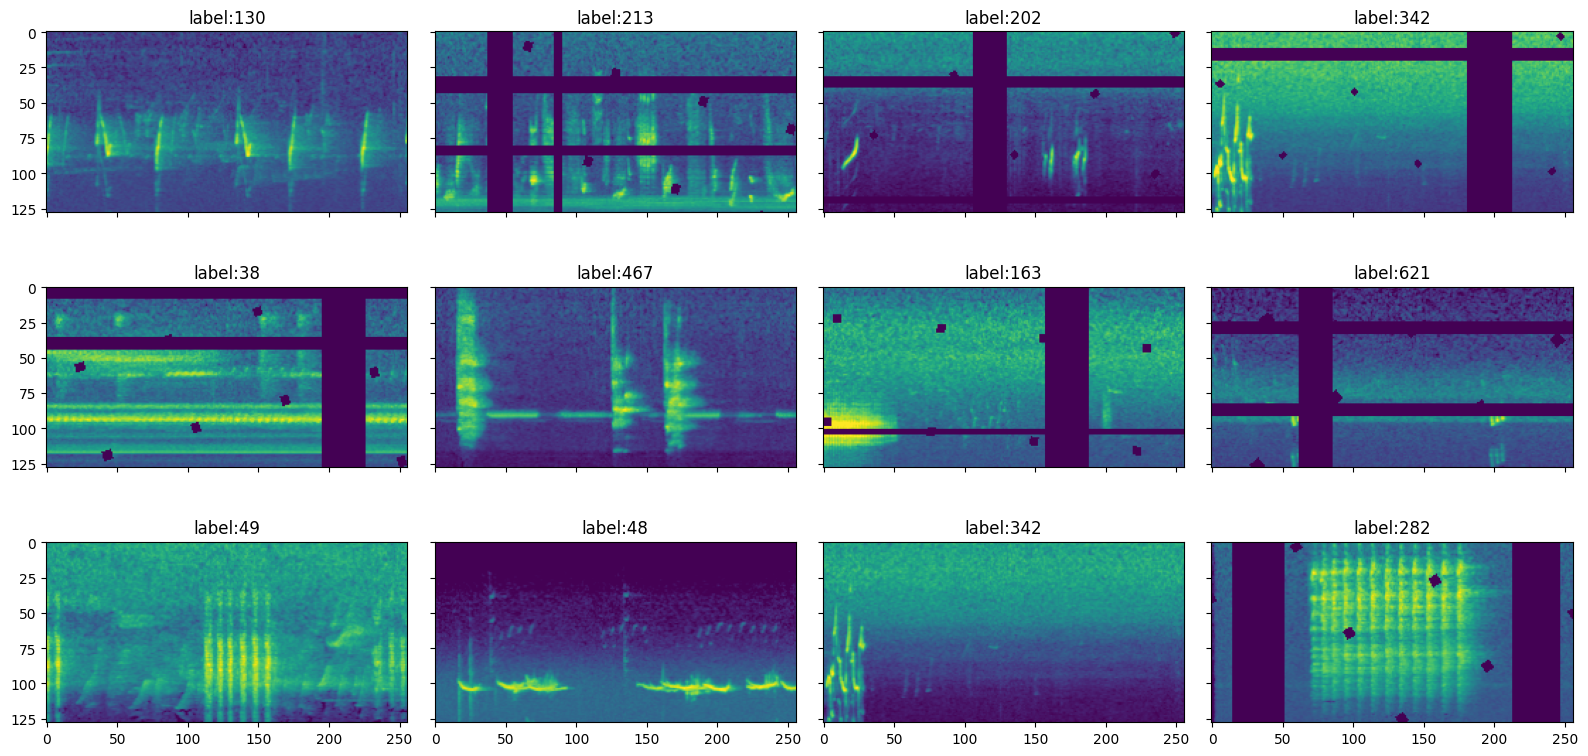

In [126]:
fig, axs = plt.subplots(3, 4, sharex='all', sharey='all', figsize=(16, 8))
for i, ax in enumerate(axs.flat):
    img = elem[0][i]
    show_img_stats(img)
    ax.imshow(img, cmap="viridis")
    ax.set_title(f"label:{np.argmax(elem[1][i].numpy())}")
plt.tight_layout()
plt.show()

# Neural network

In [128]:
model_name = "ResNet152V2"
model = ModelTrainer(
    model_name=model_name,
    img_shape=(128, 256, 1),
    n_classes=667,
    dropout_rate=0.2,
    label_smoothing=0.1,
    weights="imagenet" ,
    model_dir="/content/drive/MyDrive/model/weights_{model_name}.weights.h5",
    fine_tune_layers=200
)

In [137]:
from sklearn.model_selection import train_test_split

train_df, valid_df = train_test_split(data, test_size=0.3, stratify=data["label"])
valid_df, test_df = train_test_split(valid_df, test_size=0.5, stratify=valid_df["label"])
print(f"Split: {len(train_df)} vs {len(valid_df)} vs {len(test_df)}")
print(f"model_name: {model_name}")

Split: 150632 vs 32278 vs 32279
model_name: ResNet152V2


In [140]:
%%time
model, history = model.train(
    train_dataset=train_ds,
    val_dataset=val_ds,
    learning_rate=1e-4,
    epochs=80
)

steps_per_epoch: 500
path_weights: /content/drive/MyDrive/model/weights_ResNet152V2.weights.h5
Epoch 1/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - acc: 0.0069 - loss: 6.4510
Epoch 1: val_loss improved from inf to 5.38406, saving model to /content/drive/MyDrive/model/weights_ResNet152V2.weights.h5
500/500 ━━━━━━━━━━━━━━━━━━━━ 141s 228ms/step - acc: 0.0069 - loss: 6.4505 - val_acc: 0.1018 - val_loss: 5.3841 - learning_rate: 1.0000e-04
Epoch 2/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - acc: 0.1273 - loss: 5.1499
Epoch 2: val_loss improved from 5.38406 to 3.92661, saving model to /content/drive/MyDrive/model/weights_ResNet152V2.weights.h5
500/500 ━━━━━━━━━━━━━━━━━━━━ 109s 218ms/step - acc: 0.1274 - loss: 5.1493 - val_acc: 0.3063 - val_loss: 3.9266 - learning_rate: 1.0000e-04
Epoch 3/200
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - acc: 0.2691 - loss: 4.1169
Epoch 3: val_loss improved from 3.92661 to 3.37775, saving model to /content/drive/MyDrive/model/weights_ResNet152V2.weight

,acc,loss,val_acc,val_loss,learning_rate
epoch,,,,,
1,0.022625,6.228916,0.101834,5.384056,0.000100
2,0.167469,4.830585,0.306339,3.926614,0.000100
3,0.287281,3.991446,0.400459,3.377750,0.000100
4,0.361250,3.589700,0.461119,3.099156,0.000100
5,0.411813,3.315785,0.511401,2.831374,0.000100
6,0.459125,3.083995,0.549724,2.657591,0.000100
7,0.483000,2.926694,0.573115,2.538660,0.000100
8,0.517406,2.781878,0.593438,2.432951,0.000100
9,0.545781,2.648621,0.612368,2.354834,0.000100


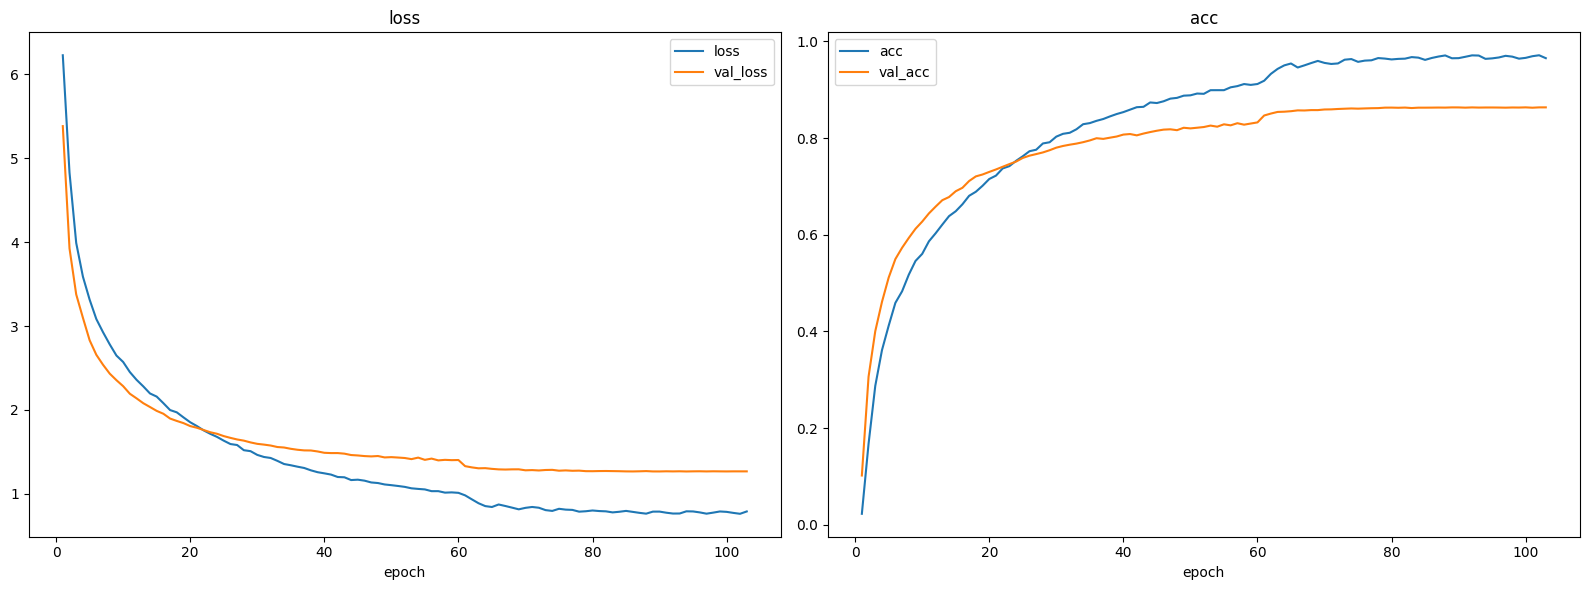

In [141]:
def show_history(history):
    """Show history"""
    history_frame = pd.DataFrame(history.history)
    history_frame.index = pd.RangeIndex(1, len(history_frame) + 1, name="epoch")
    display(history_frame.style\
        .highlight_min(color='lightgreen', subset=['val_loss'])\
        .highlight_max(color='lightgreen', subset=['val_acc'])
    )
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    history_frame.loc[:, ['loss', 'val_loss']].plot(ax=ax[0], title='loss')
    history_frame.loc[:, ['acc', 'val_acc']].plot(ax=ax[1], title='acc')
    plt.tight_layout()
    plt.show()
    
show_history(history)

# Evaluation

In [143]:
test_ds = preprocessor.create_validation_dataset(test_df)

In [144]:
true_labels = []
i=0
test_ds_size = test_ds.cardinality().numpy()
print(test_ds_size)
for batch in test_ds:
    _, batch_labels = batch  # assuming that labels are the second element of the batch tuple
    true_labels.extend(batch_labels.numpy().tolist())
    i+=1

505


In [145]:
pred_labels = model.predict(test_ds, verbose=1)

505/505 ━━━━━━━━━━━━━━━━━━━━ 28s 55ms/step


In [147]:
from sklearn.metrics import accuracy_score
true_label = np.array(true_labels)
true_label = np.argmax(true_labels, axis=1)

pred_label=tf.argmax(pred_labels, axis=1).numpy()
# # assume y_true and y_pred are your true and predicted labels, respectively
acc = accuracy_score(true_label, pred_label)
print(acc)

0.8609932154032033


In [148]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
label_encoder.fit(data.label)

def decode_label(label):
    integer_encoded = label_encoder.transform(label)
    return tf.one_hot(integer_encoded, depth=model.n_classes), integer_encoded

In [149]:
_, tru_label = decode_label(data[cfg.label].values)

In [150]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
precision = precision_score(true_label, pred_label, average='macro')
recall = recall_score(true_label, pred_label,  average='macro')
f1_score = f1_score(true_label, pred_label, average='macro')

print("Precision: ", precision)
print("Recall: ", recall)
print("F1_score: ", f1_score)

true_label_str = label_encoder.inverse_transform(true_label)
pred_label_str = label_encoder.inverse_transform(pred_label)

# classification_report
print(classification_report(true_label_str, pred_label_str))

Precision:  0.8643491942116096
Recall:  0.8563752398591415
F1_score:  0.8579939150788866
                                 precision    recall  f1-score   support

           Acropternis orthonyx       0.97      0.92      0.95        75
       Amblycercus holosericeus       0.76      0.81      0.79        27
           Ammodramus aurifrons       0.83      0.84      0.84        58
           Ammodramus humeralis       0.86      0.82      0.84        74
          Ammodramus savannarum       0.84      0.88      0.86        75
     Anabacerthia striaticollis       0.73      0.81      0.77        27
     Anabacerthia variegaticeps       0.77      0.93      0.85        44
              Anairetes parulus       0.84      0.89      0.86        36
          Andigena nigrirostris       0.75      0.84      0.79        63
       Anisognathus igniventris       0.86      0.88      0.87        34
        Anisognathus lacrymosus       1.00      0.81      0.89        26
        Anisognathus somptuosus   

In [151]:
import pickle
with open(f"/content/drive/MyDrive/model/label_encoder_{model_name}.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

In [152]:
test_df.to_csv(f"/content/drive/MyDrive/test_{model_name}.csv")

In [153]:
#from google.colab import runtime
#runtime.unassign()